# Steam Game Reviews — Unsupervised topic modelling with LDA

## tl;dr

This notebook implements the unsupervised topic-modelling part of the assignment using the same **gensim LDA workflow demonstrated in the lecture notebook**. The dictionary and final model use the canonical full English corpus. Candidate topic counts are compared on a reproducible development subset because repeatedly fitting several models to all 843,094 documents would add substantial runtime without improving the model-selection logic.

The notebook exports candidate coherence/perplexity scores, top words, full-corpus topic prevalence, topic-by-sentiment summaries, a static figure and an interactive pyLDAvis file.

## Context & Methods

### Key assumptions

- LDA is used as a lecture-aligned, interpretable baseline. It represents each review as a mixture of word-distribution topics and does not understand context in the transformer sense.
- The full corpus defines the vocabulary. Tokens appearing in fewer than 50 reviews, in more than 50% of reviews, or outside the 30,000 most frequent retained terms are removed.
- Four candidate topic counts are compared on 100,000 reviews using c_v coherence and held-corpus log perplexity. The highest-coherence count is then refitted on the complete English corpus.
- Topic numbers have no inherent meaning. Human-readable labels should be assigned only after inspecting the exported top words and example reviews.

## Data

### 1. Setup and load canonical outputs

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from gensim import corpora
from gensim.models import CoherenceModel, LdaMulticore
from gensim.corpora import MmCorpus

warnings.filterwarnings("ignore")

SEED = 42
CANDIDATE_TOPICS = [5, 8, 10, 12]
MODEL_SELECTION_ROWS = 100_000
COHERENCE_ROWS = 30_000
WORKERS = 6

def find_project_dir(markers=("Data", "data", "outputs"), max_up=4):
    """Locate the project root by walking up from the working directory.

    Portable across macOS, Windows and Linux: no hard-coded absolute paths, and it
    works whether the notebook sits in the project root or in a subfolder.
    """
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents][: max_up + 1]:
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(
        f"Could not locate the project root starting from {start}.\n"
        f"Expected a folder containing one of {markers}.\n"
        "Open the notebook from inside the project folder (the one holding Data/)."
    )

PROJECT_DIR = find_project_dir()

OUTPUT_DIR = PROJECT_DIR / "outputs"
DATA_PATH = OUTPUT_DIR / "data" / "prepared_reviews_full.parquet"
SAMPLE_PATH = OUTPUT_DIR / "data" / "modelling_sample_120k.parquet"
TOPIC_DIR = OUTPUT_DIR / "topic_models"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
for folder in [TOPIC_DIR, TABLE_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

full_text = pd.read_parquet(DATA_PATH, columns=["raw_row_id", "game_name", "target", "clean_review"])
model_sample = pd.read_parquet(SAMPLE_PATH, columns=["raw_row_id", "game_name", "target", "clean_review"])

print("Full English corpus:", f"{len(full_text):,}", "reviews")
print("Games:", full_text["game_name"].nunique())
print("Modelling sample:", f"{len(model_sample):,}")

Full English corpus: 843,094 reviews
Games: 242
Modelling sample: 120,000


### 2. Build the full-corpus dictionary

In [2]:
def iter_tokens(text_series):
    for text in text_series:
        yield str(text).split()

dictionary_path = TOPIC_DIR / "lda_dictionary.dict"
corpus_path = TOPIC_DIR / "full_corpus.mm"

dictionary = corpora.Dictionary(iter_tokens(full_text["clean_review"]))
vocabulary_before = len(dictionary)
dictionary.filter_extremes(no_below=50, no_above=0.50, keep_n=30_000)
dictionary.compactify()
dictionary.save(str(dictionary_path))

print("Vocabulary before filtering:", f"{vocabulary_before:,}")
print("Vocabulary after filtering:", f"{len(dictionary):,}")
print("Saved dictionary:", dictionary_path)

Vocabulary before filtering: 320,046
Vocabulary after filtering: 19,027
Saved dictionary: /Users/ioannis_tsantilas/Tsantil/Deree/MSc Data Science/ITC6110B1 - NATURAL LANGUAGE PROCESSING - SPRING TERM 2026/Group Project/outputs/topic_models/lda_dictionary.dict


### 3. Serialize a reusable bag-of-words corpus

In [3]:
MmCorpus.serialize(
    str(corpus_path),
    (dictionary.doc2bow(tokens) for tokens in iter_tokens(full_text["clean_review"])),
)
full_corpus = MmCorpus(str(corpus_path))

nonempty_documents = sum(1 for bow in full_corpus if len(bow) > 0)
print("Corpus documents:", f"{len(full_corpus):,}")
print("Documents with at least one retained token:", f"{nonempty_documents:,}")
print("Serialized corpus size (MB):", round(corpus_path.stat().st_size / 1024**2, 1))

Corpus documents: 843,094
Documents with at least one retained token: 840,825
Serialized corpus size (MB): 314.9


## Results

### 4. Compare candidate topic counts

In [4]:
selection_sample = model_sample.sample(n=MODEL_SELECTION_ROWS, random_state=SEED).reset_index(drop=True)
selection_tokens = [text.split() for text in selection_sample["clean_review"]]
selection_corpus = [dictionary.doc2bow(tokens) for tokens in selection_tokens]
coherence_texts = selection_tokens[:COHERENCE_ROWS]

candidate_rows = []
candidate_models = {}
for topic_count in CANDIDATE_TOPICS:
    print(f"Training candidate with {topic_count} topics...")
    model = LdaMulticore(
        corpus=selection_corpus,
        id2word=dictionary,
        num_topics=topic_count,
        random_state=SEED,
        chunksize=2_000,
        passes=3,
        iterations=75,
        alpha="asymmetric",
        eta="auto",
        workers=WORKERS,
        per_word_topics=False,
    )
    coherence = CoherenceModel(
        model=model,
        texts=coherence_texts,
        dictionary=dictionary,
        coherence="c_v",
        processes=WORKERS,
    ).get_coherence()
    log_perplexity = model.log_perplexity(selection_corpus)
    candidate_rows.append({
        "topics": topic_count,
        "c_v_coherence": coherence,
        "log_perplexity_bound": log_perplexity,
    })
    candidate_models[topic_count] = model

candidate_results = pd.DataFrame(candidate_rows).sort_values("topics").reset_index(drop=True)
candidate_results.to_csv(TABLE_DIR / "lda_model_selection.csv", index=False)
display(candidate_results.style.format({"c_v_coherence": "{:.3f}", "log_perplexity_bound": "{:.3f}"}))

selected_topics = int(candidate_results.loc[candidate_results["c_v_coherence"].idxmax(), "topics"])
print("Selected topic count by maximum c_v coherence:", selected_topics)

Training candidate with 5 topics...
Training candidate with 8 topics...
Training candidate with 10 topics...
Training candidate with 12 topics...


,topics,c_v_coherence,log_perplexity_bound
0,5,0.363,-7.846
1,8,0.390,-7.842
2,10,0.397,-7.844
3,12,0.384,-7.857


Selected topic count by maximum c_v coherence: 10


### 5. Plot model-selection evidence

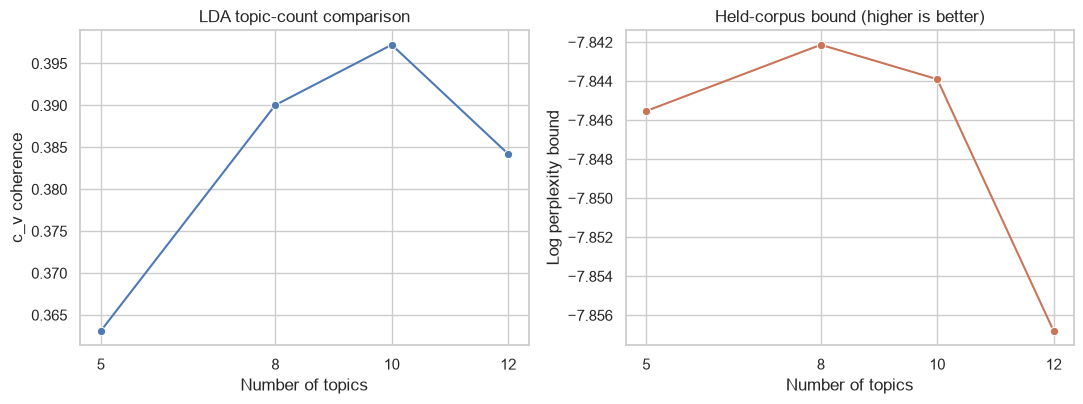

In [5]:
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.lineplot(data=candidate_results, x="topics", y="c_v_coherence", marker="o", color="#4F79B5", ax=axes[0])
axes[0].set(title="LDA topic-count comparison", xlabel="Number of topics", ylabel="c_v coherence")
sns.lineplot(data=candidate_results, x="topics", y="log_perplexity_bound", marker="o", color="#C8755A", ax=axes[1])
axes[1].set(title="Held-corpus bound (higher is better)", xlabel="Number of topics", ylabel="Log perplexity bound")
for ax in axes:
    ax.set_xticks(CANDIDATE_TOPICS)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "lda_model_selection.png", dpi=180, bbox_inches="tight")
plt.show()

### 6. Refit the selected LDA model on the complete corpus

In [6]:
full_corpus = MmCorpus(str(corpus_path))
final_model = LdaMulticore(
    corpus=full_corpus,
    id2word=dictionary,
    num_topics=selected_topics,
    random_state=SEED,
    chunksize=4_000,
    passes=3,
    iterations=100,
    alpha="asymmetric",
    eta="auto",
    workers=WORKERS,
    per_word_topics=False,
)
model_path = TOPIC_DIR / "lda_full.model"
final_model.save(str(model_path))
print("Saved final full-corpus model:", model_path)

Saved final full-corpus model: /Users/ioannis_tsantilas/Tsantil/Deree/MSc Data Science/ITC6110B1 - NATURAL LANGUAGE PROCESSING - SPRING TERM 2026/Group Project/outputs/topic_models/lda_full.model


### 7. Inspect and export topic words

In [7]:
topic_rows = []
for topic_id, terms in final_model.show_topics(num_topics=-1, num_words=12, formatted=False):
    print(f"Topic {topic_id}:", ", ".join(word for word, _ in terms))
    for rank, (word, probability) in enumerate(terms, start=1):
        topic_rows.append({
            "topic": topic_id,
            "rank": rank,
            "word": word,
            "probability": probability,
        })

topic_words = pd.DataFrame(topic_rows)
topic_words.to_csv(TABLE_DIR / "lda_topic_words.csv", index=False)
display(topic_words.head(24))

Topic 0: fun, great, like, it's, games, really, good, love, play, best, just, played
Topic 1: product, free, received, play, good, not, buy, just, dont, life, hate, like
Topic 2: not, like, just, dlc, car, no, better, cars, racing, buy, new, it's
Topic 3: not, no, just, time, got, fix, steam, bugs, day, can't, update, like
Topic 4: play, time, not, just, hours, fun, playing, don't, like, it's, people, friends
Topic 5: players, play, mode, new, player, maps, different, community, multiplayer, not, mods, golf
Topic 6: early, access, review, fun, good, great, like, it's, skate, love, best, really
Topic 7: story, not, like, world, it's, time, games, just, experience, gameplay, feel, characters
Topic 8: good, bad, just, bugs, not, grind, it's, long, easy, average, graphics, fps
Topic 9: not, like, just, it's, no, ai, really, time, don't, units, make, war


,topic,rank,word,probability
0,0,1,fun,0.024174
1,0,2,great,0.022048
2,0,3,like,0.021678
3,0,4,it's,0.019187
4,0,5,games,0.018986
5,0,6,really,0.018101
6,0,7,good,0.016879
7,0,8,love,0.013974
8,0,9,play,0.013837
9,0,10,best,0.013092


### 8. Topic-word figure

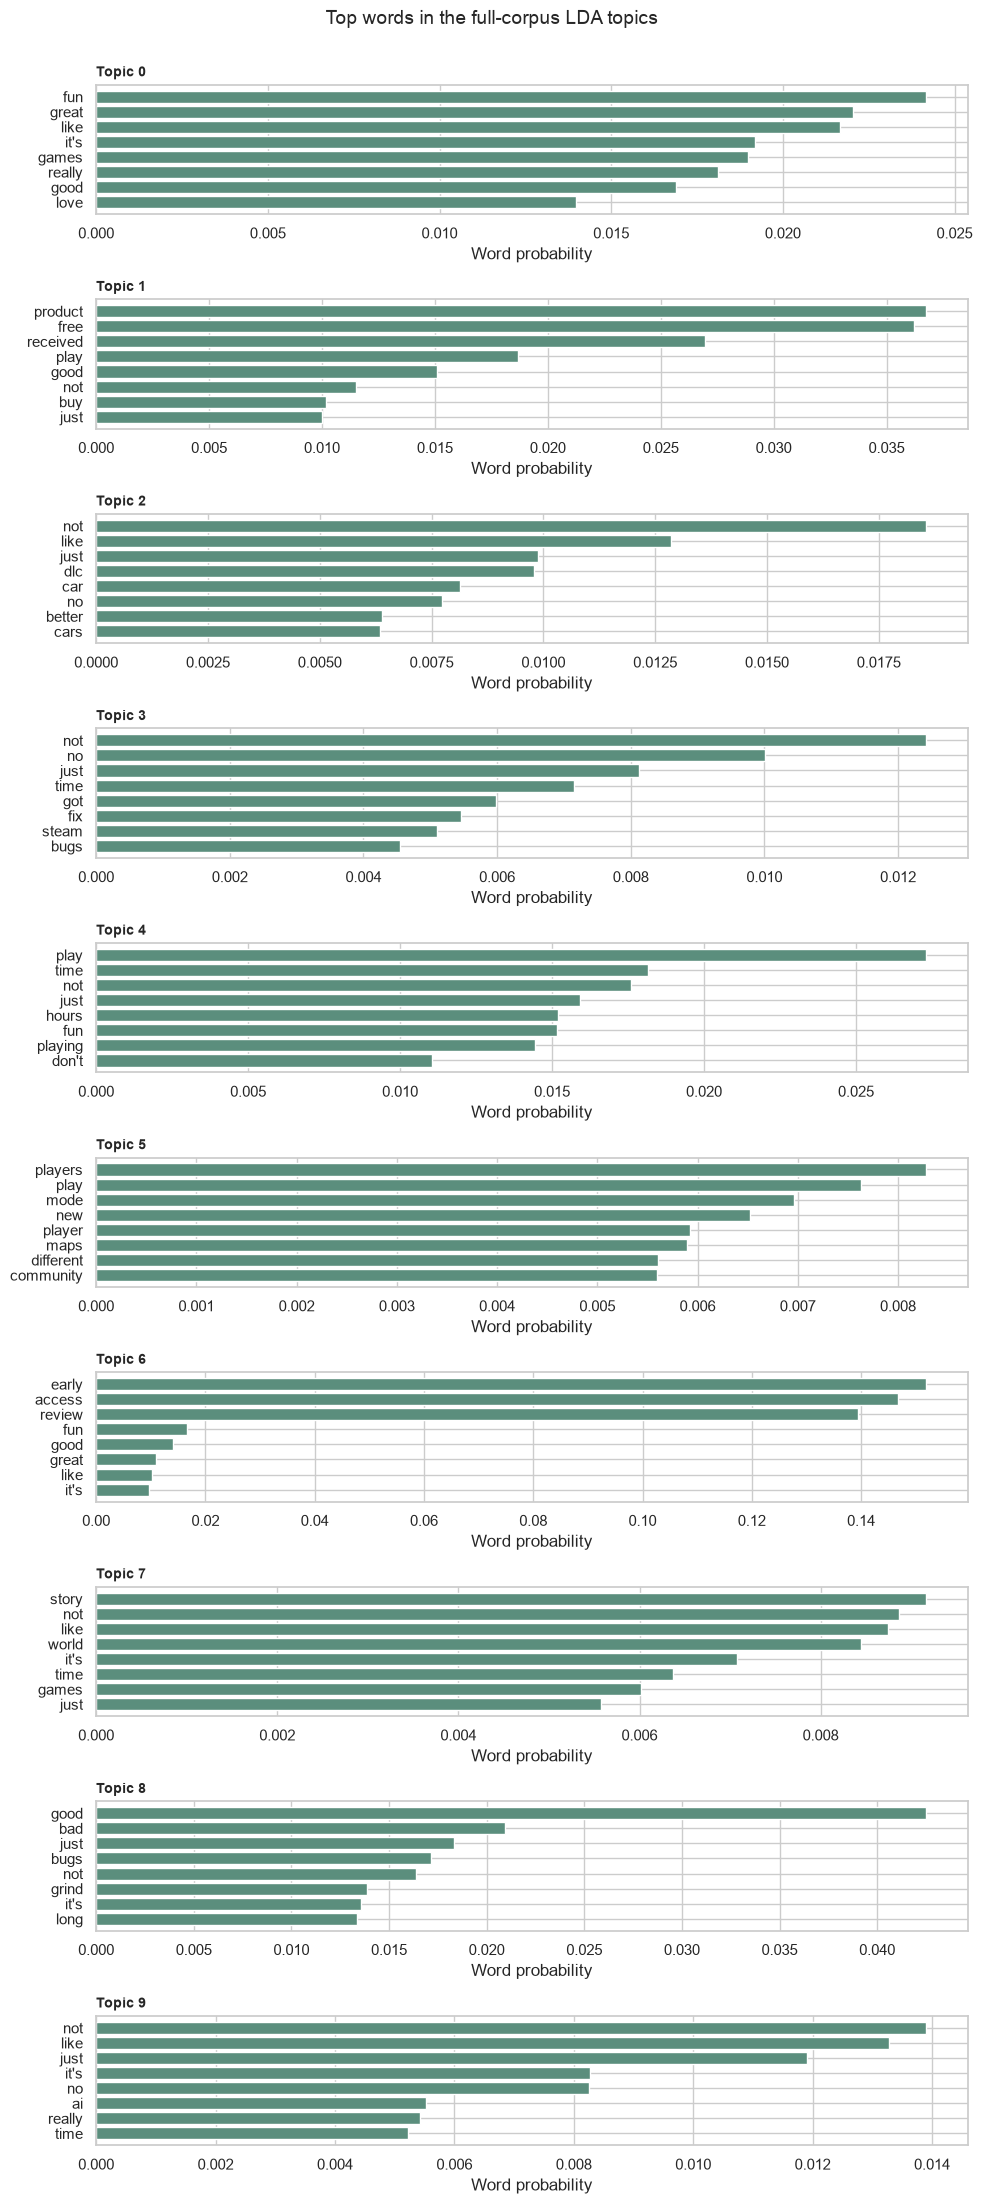

In [8]:
top_plot = topic_words.loc[topic_words["rank"].le(8)].copy()
fig, axes = plt.subplots(selected_topics, 1, figsize=(10, max(2.2 * selected_topics, 8)), squeeze=False)
for topic_id in range(selected_topics):
    ax = axes[topic_id, 0]
    part = top_plot.loc[top_plot["topic"].eq(topic_id)].sort_values("probability")
    ax.barh(part["word"], part["probability"], color="#5B8E7D")
    ax.set_title(f"Topic {topic_id}", loc="left", fontsize=10, fontweight="bold")
    ax.set_xlabel("Word probability")
fig.suptitle("Top words in the full-corpus LDA topics", y=1.001, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "lda_topic_words.png", dpi=180, bbox_inches="tight")
plt.show()

### 9. Estimate full-corpus prevalence

In [9]:
full_corpus = MmCorpus(str(corpus_path))
topic_probability_sum = np.zeros(selected_topics, dtype=np.float64)
dominant_counts = np.zeros(selected_topics, dtype=np.int64)

for bow in full_corpus:
    distribution = np.array([
        probability for _, probability in final_model.get_document_topics(bow, minimum_probability=0.0)
    ])
    topic_probability_sum += distribution
    dominant_counts[int(distribution.argmax())] += 1

topic_prevalence = pd.DataFrame({
    "topic": np.arange(selected_topics),
    "mean_topic_probability": topic_probability_sum / len(full_corpus),
    "dominant_review_count": dominant_counts,
    "dominant_review_share": dominant_counts / len(full_corpus),
}).sort_values("mean_topic_probability", ascending=False)
topic_prevalence.to_csv(TABLE_DIR / "lda_topic_prevalence.csv", index=False)
display(topic_prevalence.style.format({
    "mean_topic_probability": "{:.1%}",
    "dominant_review_share": "{:.1%}",
}))

,topic,mean_topic_probability,dominant_review_count,dominant_review_share
0,0,22.6%,206121,24.4%
4,4,11.7%,105447,12.5%
1,1,10.5%,78814,9.3%
6,6,10.5%,96354,11.4%
2,2,9.8%,81848,9.7%
3,3,9.6%,77880,9.2%
7,7,9.3%,82647,9.8%
9,9,6.9%,60017,7.1%
5,5,5.4%,34162,4.1%
8,8,3.6%,19804,2.3%


### 10. Compare dominant topics by recommendation label

In [10]:
sample_dominant_topics = []
for text in model_sample["clean_review"]:
    bow = dictionary.doc2bow(text.split())
    distribution = final_model.get_document_topics(bow, minimum_probability=0.0)
    sample_dominant_topics.append(max(distribution, key=lambda item: item[1])[0])

topic_sentiment = model_sample[["target"]].copy()
topic_sentiment["topic"] = sample_dominant_topics
topic_by_sentiment = (
    topic_sentiment.groupby(["topic", "target"]).size().rename("reviews").reset_index()
)
topic_by_sentiment["recommendation"] = topic_by_sentiment["target"].map({0: "Not Recommended", 1: "Recommended"})
topic_by_sentiment["within_topic_share"] = topic_by_sentiment["reviews"] / topic_by_sentiment.groupby("topic")["reviews"].transform("sum")
topic_by_sentiment.to_csv(TABLE_DIR / "lda_topic_by_sentiment.csv", index=False)
display(topic_by_sentiment.style.format({"within_topic_share": "{:.1%}"}))

,topic,target,reviews,recommendation,within_topic_share
0,0,0,1274,Not Recommended,4.3%
1,0,1,28140,Recommended,95.7%
2,1,0,2299,Not Recommended,20.4%
3,1,1,8950,Recommended,79.6%
4,2,0,5319,Not Recommended,45.3%
5,2,1,6431,Recommended,54.7%
6,3,0,4298,Not Recommended,39.1%
7,3,1,6698,Recommended,60.9%
8,4,0,4990,Not Recommended,33.3%
9,4,1,10003,Recommended,66.7%


### 11. Interactive pyLDAvis view on a bounded sample

In [11]:
import sys
!{sys.executable} -m pip install pyLDAvis

In [12]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

visualisation_corpus = selection_corpus[:30_000]
panel = gensimvis.prepare(
    final_model,
    visualisation_corpus,
    dictionary,
    sort_topics=False,
    n_jobs=WORKERS,
)
visualisation_path = TOPIC_DIR / "lda_visualisation.html"
pyLDAvis.save_html(panel, str(visualisation_path))
print("Saved interactive topic visualisation:", visualisation_path)
pyLDAvis.enable_notebook()
panel   

Saved interactive topic visualisation: /Users/ioannis_tsantilas/Tsantil/Deree/MSc Data Science/ITC6110B1 - NATURAL LANGUAGE PROCESSING - SPRING TERM 2026/Group Project/outputs/topic_models/lda_visualisation.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.015498  0.068258       1        1  13.047558
1      0.051921 -0.268429       2        1   4.134593
2     -0.026050 -0.010634       3        1   9.833465
3     -0.046279 -0.119408       4        1   9.867218
4     -0.015769 -0.033125       5        1  13.108021
5     -0.125939  0.055137       6        1   7.399533
6     -0.001618  0.141043       7        1   4.110866
7     -0.069195  0.082101       8        1  18.241032
8      0.318685  0.070700       9        1   3.704832
9     -0.070258  0.014357      10        1  16.552882, topic_info=           Term         Freq        Total Category  logprob  loglift
170       early  6781.000000  6781.000000  Default  30.0000  30.0000
766      access  6484.000000  6484.000000  Default  29.0000  29.0000
1771     review  7227.000000  7227.000000  Default  28.0000  28.0000
138        good  8282.000000  8282.000000  Default  27.0000  27.0000
258        free  2751.000000  2751.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
404        want   533.289289  3562.577351  Topic10  -5.8004  -0.1006
21         play   599.063714  9233.539611  Topic10  -5.6841  -0.9366
452   different   492.774073  2227.623845  Topic10  -5.8794   0.2900
427      better   504.763553  3274.575601  Topic10  -5.8553  -0.0712
470       games   505.370178  6401.391202  Topic10  -5.8541  -0.7404

[965 rows x 6 columns], token_table=       Topic      Freq     Term
term                           
1681       9  1.005509      'w'
766        1  0.000154   access
766        3  0.000154   access
766        4  0.004164   access
766        5  0.000463   access
...      ...       ...      ...
11795      5  0.005807  zombies
11795      6  0.908814  zombies
11795      7  0.011614  zombies
11795      9  0.002904  zombies
11795     10  0.005807  zombies

[3372 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

## Takeaways

In [13]:
best_row = candidate_results.loc[candidate_results["c_v_coherence"].idxmax()]
largest_topic = topic_prevalence.iloc[0]
print(f"Selected {selected_topics} topics using the highest candidate c_v coherence ({best_row['c_v_coherence']:.3f}).")
print(f"The most prevalent topic is Topic {int(largest_topic['topic'])}, with mean probability {largest_topic['mean_topic_probability']:.1%}.")
print("Interpret topics from their word lists and representative reviews; topic numbers alone are not labels.")
print("LDA gives a useful lexical overview, but mixed-topic reviews and informal language make boundaries approximate.")

Selected 10 topics using the highest candidate c_v coherence (0.397).
The most prevalent topic is Topic 0, with mean probability 22.6%.
Interpret topics from their word lists and representative reviews; topic numbers alone are not labels.
LDA gives a useful lexical overview, but mixed-topic reviews and informal language make boundaries approximate.


## Checks

In [14]:
assert len(full_text) == 843_094
assert len(full_corpus) == len(full_text)
assert len(dictionary) > 1_000
assert selected_topics in CANDIDATE_TOPICS
assert len(topic_words) == selected_topics * 12
assert np.isclose(topic_prevalence["mean_topic_probability"].sum(), 1.0, atol=1e-3)
assert dominant_counts.sum() == len(full_corpus)
assert len(sample_dominant_topics) == len(model_sample)
assert model_path.exists()
assert visualisation_path.exists()
print("All topic-modelling checks passed.")

All topic-modelling checks passed.
